# Boosted Endemble Experiments

In [1]:
%run data_loader.ipynb

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

from sklearn.ensemble import HistGradientBoostingClassifier

Config loaded
preprocess_binary() defined
load_all_datasets() defined
Project root:          /Users/yp_home/Documents/IDS_project
CICIDS2018 folder exists: True
load_cicids2018() defined


In [2]:
datasets = load_all_datasets()

print(f"Loaded: {list(datasets.keys())}")

Loading 8 dataset(s): ['monday', 'bruteforce', 'dos', 'web_attacks', 'infiltration', 'botnet', 'portscan', 'ddos']

  [monday]  Monday-WorkingHours.pcap_ISCX.csv
           raw (529918, 79)  ->  clean (502650, 81)  (attack rate 0.0%)
  [bruteforce]  Tuesday-WorkingHours.pcap_ISCX.csv
           raw (445909, 79)  ->  clean (421626, 81)  (attack rate 2.2%)
  [dos]  Wednesday-workingHours.pcap_ISCX.csv
           raw (692703, 79)  ->  clean (610492, 81)  (attack rate 31.7%)
  [web_attacks]  Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
           raw (170366, 79)  ->  clean (164179, 81)  (attack rate 1.3%)
  [infiltration]  Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
           raw (288602, 79)  ->  clean (252790, 81)  (attack rate 0.0%)
  [botnet]  Friday-WorkingHours-Morning.pcap_ISCX.csv
           raw (191033, 79)  ->  clean (184044, 81)  (attack rate 1.1%)
  [portscan]  Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
           raw (286467, 79)  ->  clea

In [3]:
combined = pd.concat(datasets.values(), ignore_index=True)

print("Combined shape:", combined.shape)

print("\nBinary label distribution:")
print(combined["Label_Binary"].value_counts())

Combined shape: (2572640, 81)

Binary label distribution:
Label_Binary
0    2146899
1     425741
Name: count, dtype: int64


In [4]:
X = combined.drop(columns=["Label", "Label_Binary", "Source_File"])
y = combined["Label_Binary"]

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (2058112, 78)
X_test : (514528, 78)


In [6]:
from sklearn.ensemble import HistGradientBoostingClassifier

In [7]:
hgb_model = HistGradientBoostingClassifier(
    max_iter=100,
    learning_rate=0.1,
    max_depth=8,
    random_state=42
)

hgb_model.fit(X_train, y_train)

,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.1
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",100
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",8
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""category"" are considered to be categorical features. The input must be an object exposing a ``__dataframe__`` method such as pandas or polars DataFrames to use this feature.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing values. All categorical values areconverted to floating point numbers. This means that categorical valuesof 1.0 and 1 are treated as the same category.Read more in the :ref:`User Guide `... versionadded:: 0.24.. versionchanged:: 1.2 Added support for feature names... versionchanged:: 1.4 Added `""from_dtype""` option... versionchanged:: 1.6 The default value changed from `None` to `""from_dtype""`.",'from_dtype

In [8]:
y_pred_hgb = hgb_model.predict(X_test)
y_scores_hgb = hgb_model.predict_proba(X_test)[:, 1]

In [9]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

print("HistGradientBoosting Results")

print("Accuracy :", round(accuracy_score(y_test, y_pred_hgb), 4))
print("Precision:", round(precision_score(y_test, y_pred_hgb), 4))
print("Recall   :", round(recall_score(y_test, y_pred_hgb), 4))
print("F1 Score :", round(f1_score(y_test, y_pred_hgb), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_scores_hgb), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_hgb))

HistGradientBoosting Results
Accuracy : 0.9989
Precision: 0.9964
Recall   : 0.997
F1 Score : 0.9967
ROC-AUC  : 1.0

Confusion Matrix:
[[429076    304]
 [   252  84896]]


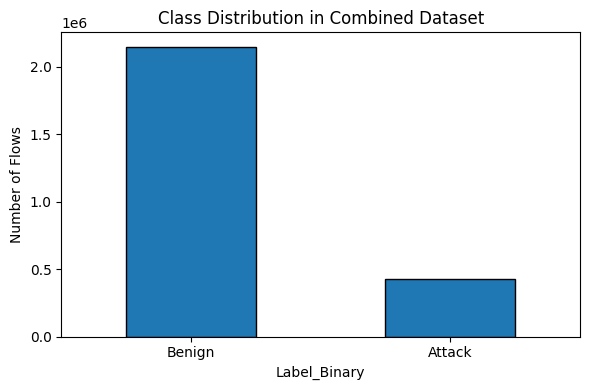

In [10]:
# Class Distribution in Combined Dataset
plt.figure(figsize=(6, 4))

combined["Label_Binary"].value_counts().sort_index().plot(
    kind="bar",
    edgecolor="black"
)

plt.xticks([0, 1], ["Benign", "Attack"], rotation=0)
plt.ylabel("Number of Flows")
plt.title("Class Distribution in Combined Dataset")
plt.tight_layout()
plt.show()

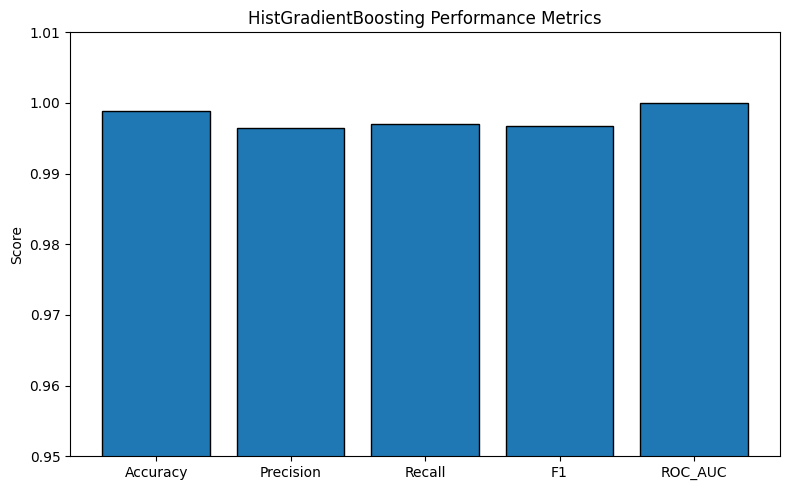

In [11]:
# Performance Metrics for HistGradientBoosting
results_df = pd.DataFrame([
    {
        "Model": "HistGradientBoosting",
        "Accuracy": accuracy_score(y_test, y_pred_hgb),
        "Precision": precision_score(y_test, y_pred_hgb),
        "Recall": recall_score(y_test, y_pred_hgb),
        "F1": f1_score(y_test, y_pred_hgb),
        "ROC_AUC": roc_auc_score(y_test, y_scores_hgb)
    }
]).round(4)

metrics = ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]

plt.figure(figsize=(8, 5))
plt.bar(
    metrics,
    [results_df.iloc[0][m] for m in metrics],
    edgecolor="black"
)

plt.ylim(0.95, 1.01)
plt.ylabel("Score")
plt.title("HistGradientBoosting Performance Metrics")
plt.tight_layout()
plt.show()

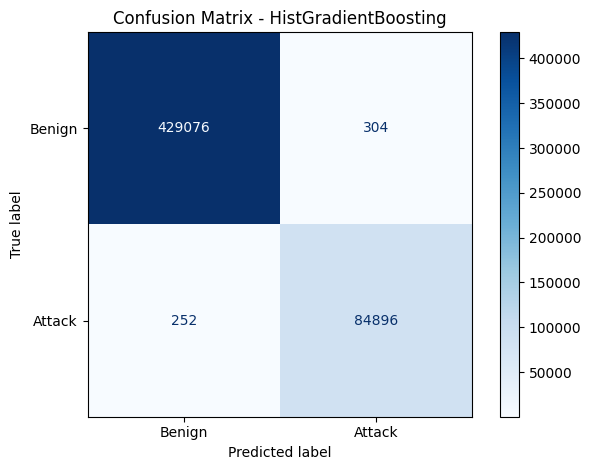

In [12]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_hgb,
    display_labels=["Benign", "Attack"],
    cmap="Blues"
)

plt.title("Confusion Matrix - HistGradientBoosting")
plt.tight_layout()
plt.show()

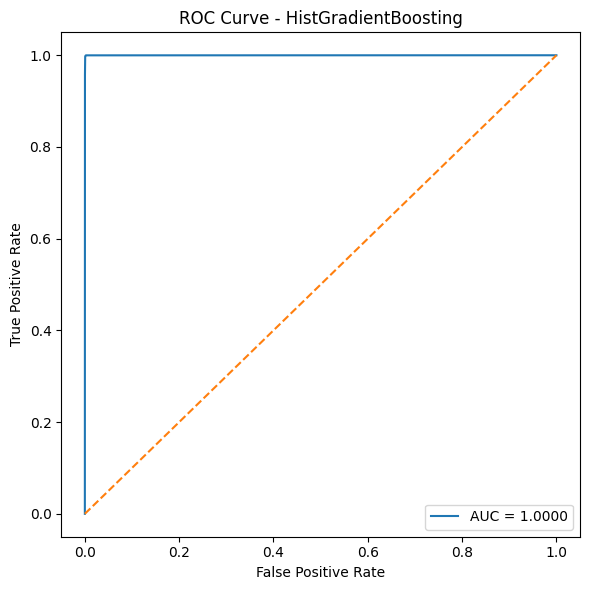

In [13]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_scores_hgb)

plt.figure(figsize=(6, 6))
plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc_score(y_test, y_scores_hgb):.4f}"
)

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - HistGradientBoosting")
plt.legend()
plt.tight_layout()
plt.show()

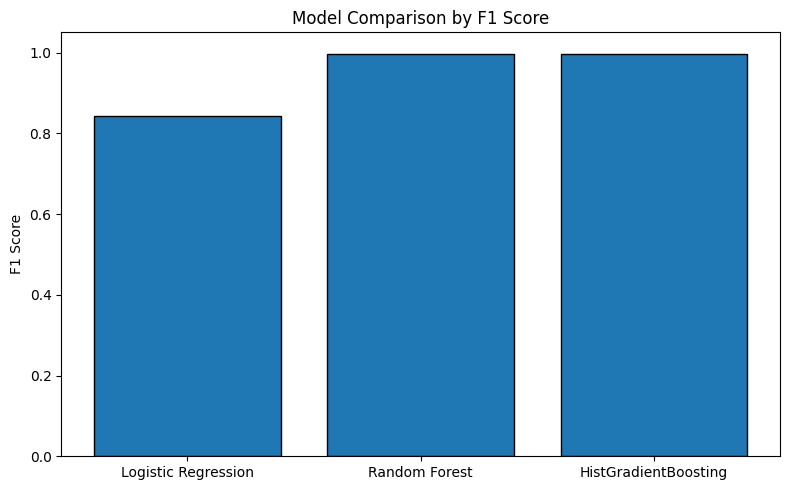

In [14]:
comparison_df = pd.DataFrame([
    ["Logistic Regression", 0.8428],
    ["Random Forest", 0.9958],
    ["HistGradientBoosting", 0.9967]
], columns=["Model", "F1"])

plt.figure(figsize=(8, 5))
plt.bar(
    comparison_df["Model"],
    comparison_df["F1"],
    edgecolor="black"
)

plt.ylim(0, 1.05)
plt.ylabel("F1 Score")
plt.title("Model Comparison by F1 Score")
plt.tight_layout()
plt.show()